<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/ML_Projects/Credit%20Card%20Fraud%20Detection/Credit_Card_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd


In [24]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('creditcard_50000rows.csv')
df.head()

Saving creditcard_50000rows.csv to creditcard_50000rows (1).csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df['Class'].value_counts()

,count
Class,
0,49852
1,148


<Axes: xlabel='Class'>

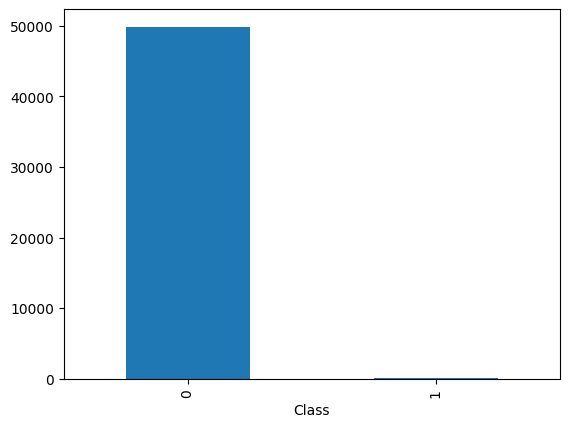

In [5]:
df['Class'].value_counts().plot(kind='bar')

In [6]:
df.shape

(50000, 31)

In [7]:
%%markdown
---
train model

---
train model


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X= df.drop('Class', axis=1)
y= df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print("CONFUSION MATRIX")
print(conf_matrix)


class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

accuracy_score(y_test, y_pred)

CONFUSION MATRIX
[[9964    2]
 [   2   32]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9966
           1       0.94      0.94      0.94        34

    accuracy                           1.00     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       1.00      1.00      1.00     10000



0.9996

In [10]:
%%markdown
---
Appling RandomeOverSample

---
Appling RandomeOverSample


In [11]:
from imblearn.over_sampling import RandomOverSampler
# Initialize RandomOverSampler
ros = RandomOverSampler()

# Perform Random Oversampling
X_ros, y_ros = ros.fit_resample(X_train, y_train)

In [12]:
y_ros.value_counts()


,count
Class,
0,39886
1,39886


In [13]:
rf_model_ros = RandomForestClassifier()

rf_model_ros.fit(X_ros, y_ros)

y_pred_ros = rf_model_ros.predict(X_test)

conf_matrix_ros = confusion_matrix(y_test, y_pred_ros)
print("Confusion Matrix (Random Oversampling):")
print(conf_matrix_ros)


class_report_ros = classification_report(y_test, y_pred_ros)
print("\nClassification Report (Random Oversampling):")
print(class_report_ros)

accuracy_ros = rf_model_ros.score(X_test, y_test)
print("Accuracy (Random Oversampling):", accuracy_ros)



Confusion Matrix (Random Oversampling):
[[9965    1]
 [   3   31]]

Classification Report (Random Oversampling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9966
           1       0.97      0.91      0.94        34

    accuracy                           1.00     10000
   macro avg       0.98      0.96      0.97     10000
weighted avg       1.00      1.00      1.00     10000

Accuracy (Random Oversampling): 0.9996


In [14]:
%%markdown
---
Applying random undersampling

---
Applying random undersampling


In [15]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X_train, y_train)

y_rus.value_counts()

,count
Class,
0,114
1,114


In [16]:
rf_model_rus = RandomForestClassifier()

rf_model_rus.fit(X_rus, y_rus)

y_pred_rus = rf_model_rus.predict(X_test)

conf_matrix_rus = confusion_matrix(y_test, y_pred_rus)
print("Confusion Matrix (Random Undersampling):")
print(conf_matrix_rus)

class_report_rus = classification_report(y_test, y_pred_rus)
print("\nClassification Report (Random Undersampling):")
print(class_report_rus)

accuracy_rus = rf_model_rus.score(X_test, y_test)
print("Accuracy (Random Undersampling):", accuracy_rus)

Confusion Matrix (Random Undersampling):
[[9902   64]
 [   0   34]]

Classification Report (Random Undersampling):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9966
           1       0.35      1.00      0.52        34

    accuracy                           0.99     10000
   macro avg       0.67      1.00      0.76     10000
weighted avg       1.00      0.99      1.00     10000

Accuracy (Random Undersampling): 0.9936


In [17]:
%%markdown
---
SMOTE

---
SMOTE


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X_train, y_train)

y_smote.value_counts()

,count
Class,
0,39886
1,39886


In [19]:
rf_model_smote = RandomForestClassifier()

rf_model_smote.fit(X_smote, y_smote)

y_pred_smote = rf_model_smote.predict(X_test)

conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (SMOTE):")
print(conf_matrix_smote)

class_report_smote = classification_report(y_test, y_pred_smote)
print("\nClassification Report (SMOTE):")
print(class_report_smote)

accuracy_smote = rf_model_smote.score(X_test, y_test)
print("Accuracy (SMOTE):", accuracy_smote)

Confusion Matrix (SMOTE):
[[9961    5]
 [   1   33]]

Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9966
           1       0.87      0.97      0.92        34

    accuracy                           1.00     10000
   macro avg       0.93      0.99      0.96     10000
weighted avg       1.00      1.00      1.00     10000

Accuracy (SMOTE): 0.9994


In [20]:
%%markdown
---
Prediction

---
Prediction


In [21]:
inputs_1 = X_test.iloc[[10]].values

prediction = rf_model_smote.predict(inputs_1)
print("Actual Class :", y_test.iloc[10])
print("Predicted Class:", prediction[0])

Actual Class : 0
Predicted Class: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [22]:
inputs_2 = X_test.iloc[[42]].values

prediction = rf_model_smote.predict(inputs_2)
print("Actual Class :", y_test.iloc[42])
print("Predicted Class:", prediction[0])

Actual Class : 0
Predicted Class: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
import joblib

# Save your trained model
joblib.dump(rf_model_smote, "credit_card_model.pkl")

print("Model saved successfully!")

Model saved successfully!
